# **Load Datset**

In [2]:
!pip install kaggle

In [1]:
path = '/content/kaggle.json'

In [3]:
!mkdir -p ~/.kaggle
!cp {path} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
  0% 0.00/66.7M [00:00<?, ?B/s]
100% 66.7M/66.7M [00:00<00:00, 1.32GB/s]


In [6]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = 'dataset'
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [7]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [8]:
len(data_0)

2236

# **Import library**

In [9]:
# Import Library yang dibutuhkan
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Tentukan lokasi folder ekstraksi
extract_folder = 'dataset'

# List semua folder digit (0 sampai 9)
digit_folders = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

print("selesai:", extract_folder)

selesai: dataset


# **Membaca, Menggabungkan, Melabeli**

In [10]:
# Inisialisasi list untuk menyimpan data dan label
X = [] # Data Gambar (Fitur)
y = [] # Label (Angka 0-9)
image_size = (28, 28) # Standar MNIST

print("Mulai membaca dan memproses gambar...")

# Looping melalui setiap folder (digit)
for label_str in digit_folders:
    label = int(label_str)
    folder_path = os.path.join(extract_folder, label_str)

    # Looping melalui setiap file gambar
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(folder_path, filename)

            # 1. Membaca gambar (Grayscale)
            img = Image.open(file_path).convert('L')

            # 2. Resize gambar ke 28x28
            img = img.resize(image_size)

            # 3. Ubah gambar menjadi array NumPy
            img_array = np.array(img)

            # 4. Tambahkan ke list X dan label ke list y
            X.append(img_array)
            y.append(label)

# Konversi list ke array NumPy
X = np.array(X)
y = np.array(y)

print("Pembacaan selesai.")
print(f"Total data gambar (X) setelah digabungkan: {X.shape}")
print(f"Total data label (y) setelah digabungkan: {y.shape}")

Mulai membaca dan memproses gambar...
Pembacaan selesai.
Total data gambar (X) setelah digabungkan: (21555, 28, 28)
Total data label (y) setelah digabungkan: (21555,)


# **Splitting, Normalisasi, dan Encoding**

In [11]:
# 1. Split Data Training dan Testing (misal 80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# 2. Normalisasi: Skala nilai piksel dari 0-255 menjadi 0-1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 3. One-Hot Encoding pada Label (Wajib untuk klasifikasi multi-kelas)
num_classes = 10
y_train_encoded = to_categorical(y_train, num_classes)
y_test_encoded = to_categorical(y_test, num_classes)

print("Data telah dipreprocessing.")
print(f"Bentuk data Training setelah di-split: {X_train.shape}")
print(f"Bentuk label Training (One-Hot): {y_train_encoded.shape}")

Data telah dipreprocessing.
Bentuk data Training setelah di-split: (17244, 28, 28)
Bentuk label Training (One-Hot): (17244, 10)


# **Membangun MLP**

In [12]:
# Inisialisasi Model Sequential
model = Sequential()

# Lapisan 1: Flatten (Input Layer)
model.add(Flatten(input_shape=(28, 28)))

# Lapisan 2: Hidden Layer 1 (Dense)
model.add(Dense(256, activation='relu'))

# Lapisan 3: Hidden Layer 2 (Dense)
model.add(Dense(128, activation='relu'))

# Lapisan 4: Output Layer
# Softmax menghasilkan probabilitas untuk setiap kelas
model.add(Dense(num_classes, activation='softmax'))

# Tampilkan ringkasan arsitektur model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

# **Kompilasi dan training**

In [13]:
# Kompilasi Model: Menentukan optimizer, loss function, dan metrik
model.compile(optimizer='adam', # Algoritma optimasi
              loss='categorical_crossentropy', # Cocok untuk One-Hot Encoding multi-kelas
              metrics=['accuracy'])

# Pelatihan Model (Fitting)
print("Memulai proses training...")
history = model.fit(X_train, y_train_encoded,
                    epochs=10, # Jumlah perulangan training
                    batch_size=32,
                    validation_data=(X_test, y_test_encoded), # Evaluasi pada data testing setiap akhir epoch
                    verbose=1)

print("Proses training selesai.")

Memulai proses training...
Epoch 1/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1282 - loss: 2.3295 - val_accuracy: 0.1812 - val_loss: 2.1318
Epoch 2/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2723 - loss: 2.0363 - val_accuracy: 0.3558 - val_loss: 1.8680
Epoch 3/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3648 - loss: 1.8398 - val_accuracy: 0.4078 - val_loss: 1.8034
Epoch 4/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4053 - loss: 1.7415 - val_accuracy: 0.4405 - val_loss: 1.6886
Epoch 5/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4493 - loss: 1.6470 - val_accuracy: 0.4178 - val_loss: 1.7153
Epoch 6/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4794 - loss: 1.5721 - val_accuracy: 0.4825 - val_loss: 1.5838
Epoch 7/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4853 - loss: 1.5379 - val_accuracy: 0.4818 - val_loss: 1.5514
Epoch 8/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5096 - loss

# **Evaluasi Model dan Analisis Performa**


--- HASIL AKHIR EVALUASI ---
Test Loss (Tingkat Kesalahan): 1.3862
Test Accuracy (Akurasi Prediksi): 54.67%


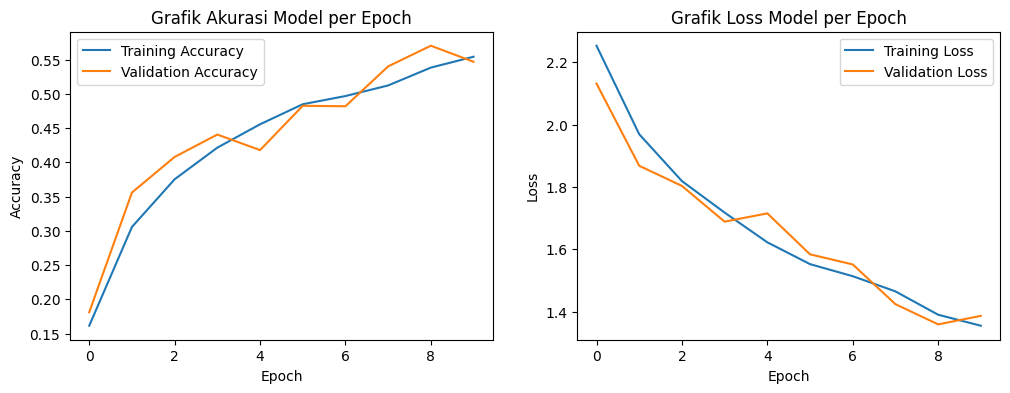

In [15]:
import matplotlib.pyplot as plt

loss, accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)

print(f"\n--- HASIL AKHIR EVALUASI ---")
print(f"Test Loss (Tingkat Kesalahan): {loss:.4f}")
print(f"Test Accuracy (Akurasi Prediksi): {accuracy * 100:.2f}%")

# 2. Plot Riwayat Training (Untuk perbandingan yang diminta tugas)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi Model per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss Model per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Jika Training Loss terus turun, tetapi Validation Loss naik, itu adalah tanda Overfitting.
# Akurasi yang stabil menunjukkan model belajar dengan baik.